# Lesson 11: Neural Networks and Deep Learning

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
**Lecture 11 of the extended econometrics and machine-learning sequence**

Neural networks are computational models inspired by the brain. Their purpose is not to reproduce biological neurons exactly, but to use simple computational units arranged in layers to learn complex nonlinear relationships from data.

A neural network learns a function

$$
\hat{y}=f_\theta(x),
$$

where $x$ is a vector of inputs, $\hat{y}$ is a prediction, and $\theta$ is the collection of trainable parameters: weights and biases.

## Learning goals

By the end of this lecture, you should be able to:

1. Define artificial neural networks and explain why they are useful for nonlinear pattern recognition.
2. Explain perceptrons, weights, biases, weighted sums, and activation functions.
3. Describe input layers, hidden layers, output layers, and forward propagation.
4. Explain why nonlinear activation functions are essential.
5. Define loss functions such as mean squared error and cross-entropy.
6. Explain gradient descent and the chain-rule logic of backpropagation.
7. Implement a small neural network from scratch with NumPy.
8. Understand initialization, learning rates, regularization, dropout, and overfitting.
9. Distinguish feedforward networks, convolutional neural networks, and recurrent neural networks.
10. Connect neural networks to real-world applications: computer vision, NLP, finance, forecasting, and generative AI.

The theme of the lecture is:

> Neural networks combine linear transformations with nonlinear activation functions to learn flexible representations of data.

In [1]:
# Core imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_classification, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, log_loss
)
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

np.random.seed(42)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

## 1. What Is an Artificial Neural Network?

An **artificial neural network**, or ANN, is a computational model made of layers of simple units called neurons. Each neuron receives inputs, forms a weighted sum, adds a bias, and applies a nonlinear activation function.

A single artificial neuron computes

$$
z = w_1x_1 + w_2x_2 + \cdots + w_kx_k + b,
$$

or in vector notation,

$$
z = w'x + b.
$$

Then it applies an activation function $\phi$:

$$
a = \phi(z).
$$

Here:

- $x_j$ is an input feature.
- $w_j$ is the weight on input $x_j$.
- $b$ is the bias or intercept.
- $z$ is the pre-activation value.
- $a$ is the activated output.

Neural networks are useful because they can learn nonlinear patterns. Traditional machine-learning methods often require the researcher to design features manually. Deep neural networks can learn intermediate features internally. This is called **representation learning** or **feature learning**.

For example:

- In computer vision, early layers may learn edges, later layers may learn shapes, and deeper layers may learn object parts.
- In natural language processing, embeddings may learn semantic relationships among words or tokens.
- In finance, a network may learn nonlinear interactions among balance-sheet variables, macro conditions, and market signals.

## 2. The Perceptron

The perceptron is the simplest neural-network unit. For binary classification, it predicts one of two classes.

Given inputs $x$, weights $w$, and bias $b$, the perceptron computes

$$
z = w'x + b.
$$

A hard-threshold perceptron uses

$$
\hat{y} =
\begin{cases}
1 & \text{if } z \geq 0,\\
0 & \text{if } z < 0.
\end{cases}
$$

This creates a linear decision boundary:

$$
w'x+b=0.
$$

The perceptron is historically important, but a single perceptron can only classify linearly separable patterns. Modern neural networks become powerful by stacking many units into hidden layers and using nonlinear activation functions.

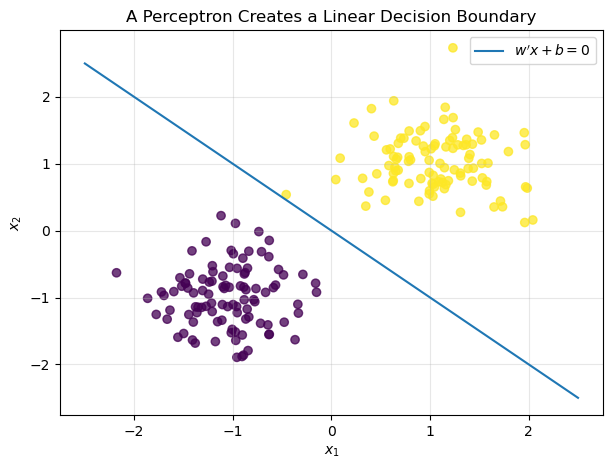

In [3]:
# Visualizing a perceptron decision boundary

np.random.seed(42)

# Create two linearly separable clusters
n = 100
x0 = np.random.normal(loc=[-1.0, -1.0], scale=0.45, size=(n, 2))
x1 = np.random.normal(loc=[1.0, 1.0], scale=0.45, size=(n, 2))

X_perc = np.vstack([x0, x1])
y_perc = np.r_[np.zeros(n), np.ones(n)]

# Manually choose a perceptron boundary
w = np.array([1.0, 1.0])
b = 0.0

xx = np.linspace(-2.5, 2.5, 100)
yy = -(w[0] * xx + b) / w[1]

plt.figure(figsize=(7, 5))
plt.scatter(X_perc[:, 0], X_perc[:, 1], c=y_perc, alpha=0.75)
plt.plot(xx, yy, label=r"$w'x+b=0$")
plt.title("A Perceptron Creates a Linear Decision Boundary")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Why Nonlinearity Matters

If a neural network used only linear transformations, then stacking many layers would still be equivalent to a single linear model.

Suppose a network has two linear layers:

$$
h = W_1x+b_1,
$$

$$
\hat{y}=W_2h+b_2.
$$

Substitute the first equation into the second:

$$
\hat{y}
=
W_2(W_1x+b_1)+b_2
=
(W_2W_1)x + (W_2b_1+b_2).
$$

This is still linear in $x$. Therefore, depth alone is not enough. Nonlinear activation functions are what allow networks to learn nonlinear patterns.

Common activation functions include:

### Sigmoid

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

The sigmoid maps real numbers into $(0,1)$.

### Hyperbolic tangent

$$
\tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}.
$$

The tanh function maps real numbers into $(-1,1)$.

### ReLU

$$
ReLU(z)=\max(0,z).
$$

ReLU is simple, fast, and widely used in deep learning.

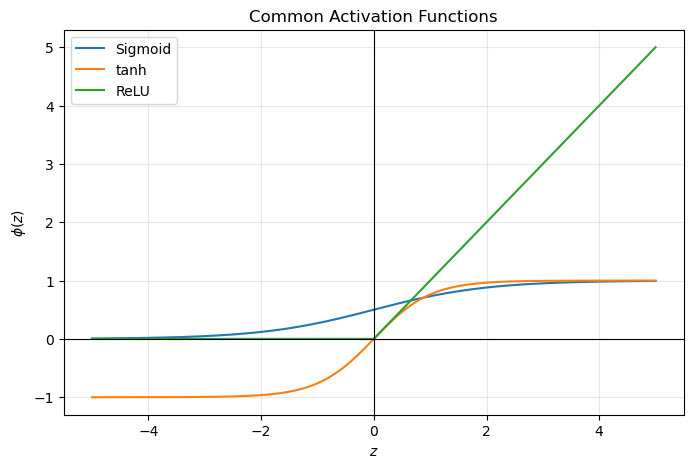

In [5]:
# Plot common activation functions

z = np.linspace(-5, 5, 500)

sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid, label="Sigmoid")
plt.plot(z, tanh, label="tanh")
plt.plot(z, relu, label="ReLU")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Common Activation Functions")
plt.xlabel("$z$")
plt.ylabel(r"$\phi(z)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Network Architecture

A standard feedforward neural network has three types of layers:

1. **Input layer**: receives the feature vector $x$.
2. **Hidden layers**: transform the inputs into learned representations.
3. **Output layer**: produces a prediction.

For a network with one hidden layer,

$$
h = \phi(W_1x+b_1),
$$

$$
\hat{y}=g(W_2h+b_2).
$$

Here:

- $W_1$ maps inputs to hidden units.
- $b_1$ shifts hidden-unit pre-activations.
- $\phi$ is the hidden-layer activation function.
- $W_2$ maps hidden units to output units.
- $b_2$ shifts the output.
- $g$ is the output activation function.

Common output choices:

- Linear output for regression.
- Sigmoid output for binary classification.
- Softmax output for multi-class classification.

For multi-class classification, softmax is

$$
p_k
=
\frac{e^{z_k}}{\sum_{j=1}^K e^{z_j}},
$$

where $p_k$ is the predicted probability of class $k$.

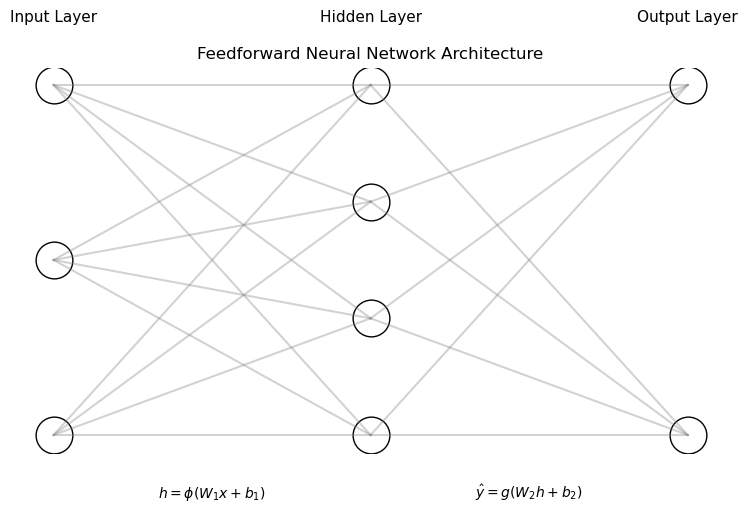

In [7]:
# Diagram of a small feedforward network

plt.figure(figsize=(9, 5))

layer_x = [0, 2.5, 5.0]
layer_sizes = [3, 4, 2]
labels = ["Input Layer", "Hidden Layer", "Output Layer"]

node_positions = []

for lx, size, label in zip(layer_x, layer_sizes, labels):
    ys = np.linspace(0, 1, size)
    positions = []
    for y in ys:
        plt.scatter(lx, y, s=700, facecolors="white", edgecolors="black")
        positions.append((lx, y))
    node_positions.append(positions)
    plt.text(lx, 1.18, label, ha="center", fontsize=11)

# Connect layers
for left_layer, right_layer in zip(node_positions[:-1], node_positions[1:]):
    for x1, y1 in left_layer:
        for x2, y2 in right_layer:
            plt.plot([x1, x2], [y1, y2], color="gray", alpha=0.35)

plt.text(1.25, -0.18, r"$h=\phi(W_1x+b_1)$", ha="center")
plt.text(3.75, -0.18, r"$\hat{y}=g(W_2h+b_2)$", ha="center")
plt.title("Feedforward Neural Network Architecture")
plt.axis("off")
plt.show()

## 5. Forward Propagation

**Forward propagation** is the process of passing data through the network to produce a prediction.

For a two-layer network:

$$
Z_1 = XW_1 + b_1,
$$

$$
A_1 = \phi(Z_1),
$$

$$
Z_2 = A_1W_2 + b_2,
$$

$$
\hat{Y}=g(Z_2).
$$

Forward propagation is just repeated matrix multiplication, addition of biases, and application of nonlinear activation functions.

For a batch of $n$ observations:

- $X$ is $n \times p$.
- $W_1$ is $p \times h$.
- $b_1$ is $1 \times h$.
- $A_1$ is $n \times h$.
- $W_2$ is $h \times q$.
- $\hat{Y}$ is $n \times q$.

The batch formulation is important because neural networks are trained efficiently using vectorized operations.

In [9]:
# Forward propagation in a tiny network

np.random.seed(42)

X_demo = np.array([
    [1.0, 0.5],
    [0.2, -1.0],
    [-0.3, 0.8]
])

W1 = np.random.normal(0, 0.5, size=(2, 4))
b1 = np.zeros((1, 4))

W2 = np.random.normal(0, 0.5, size=(4, 1))
b2 = np.zeros((1, 1))

def relu_fn(z):
    return np.maximum(0, z)

def sigmoid_fn(z):
    return 1 / (1 + np.exp(-z))

Z1 = X_demo @ W1 + b1
A1 = relu_fn(Z1)
Z2 = A1 @ W2 + b2
Yhat = sigmoid_fn(Z2)

print("Hidden pre-activations Z1:")
print(np.round(Z1, 3))
print("\nHidden activations A1:")
print(np.round(A1, 3))
print("\nOutput predictions:")
print(np.round(Yhat, 3))

Hidden pre-activations Z1:
[[ 0.19  -0.128  0.719  0.953]
 [ 0.167  0.103 -0.725 -0.231]
 [-0.168 -0.073  0.535  0.079]]

Hidden activations A1:
[[0.19  0.    0.719 0.953]
 [0.167 0.103 0.    0.   ]
 [0.    0.    0.535 0.079]]

Output predictions:
[[0.393]
 [0.497]
 [0.465]]


## 6. Loss Functions

A neural network needs a criterion for measuring how wrong its predictions are. This is the **loss function**.

### Mean Squared Error

For regression,

$$
MSE
=
\frac{1}{n}\sum_{i=1}^n (y_i-\hat{y}_i)^2.
$$

MSE penalizes large errors more heavily than small errors.

### Binary Cross-Entropy

For binary classification,

$$
BCE
=
-\frac{1}{n}
\sum_{i=1}^n
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

This loss is appropriate when $\hat{p}_i$ is a predicted probability.

### Multi-Class Cross-Entropy

For $K$ classes,

$$
CE
=
-\frac{1}{n}
\sum_{i=1}^n
\sum_{k=1}^K
1(y_i=k)\log(\hat{p}_{ik}).
$$

The loss function defines what the network is trying to minimize.

In [11]:
# Compare MSE and binary cross-entropy for probability predictions

y_true = np.array([1, 1, 0, 0])
pred_good = np.array([0.95, 0.80, 0.10, 0.20])
pred_bad = np.array([0.55, 0.45, 0.50, 0.60])

def binary_cross_entropy(y, p):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

comparison = pd.DataFrame({
    "Prediction Set": ["Good probabilities", "Bad probabilities"],
    "MSE": [
        mean_squared_error(y_true, pred_good),
        mean_squared_error(y_true, pred_bad)
    ],
    "Binary Cross-Entropy": [
        binary_cross_entropy(y_true, pred_good),
        binary_cross_entropy(y_true, pred_bad)
    ]
})

comparison

,Prediction Set,MSE,Binary Cross-Entropy
0,Good probabilities,0.023125,0.150735
1,Bad probabilities,0.278750,0.751446


## 7. Optimization and Gradient Descent

Training a neural network means choosing parameters $\theta$ to minimize the loss:

$$
\hat{\theta}
=
\arg\min_\theta L(\theta).
$$

Gradient descent updates parameters by moving opposite the gradient:

$$
\theta^{(m+1)}
=
\theta^{(m)}
-
\eta \nabla_\theta L(\theta^{(m)}).
$$

Here $\eta$ is the **learning rate**.

- If $\eta$ is too small, learning is slow.
- If $\eta$ is too large, training may become unstable.
- If $\eta$ is well-chosen, the loss declines smoothly.

Neural networks are usually trained using variants of stochastic gradient descent. Instead of computing the gradient on the full sample, stochastic methods use small batches of observations.

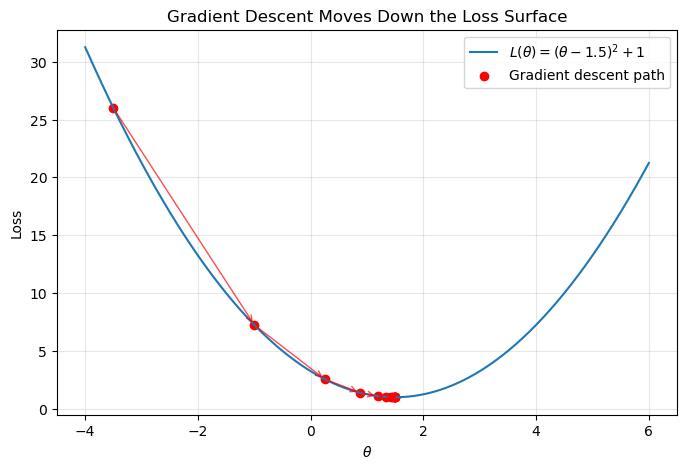

In [13]:
# Visualize gradient descent on a simple quadratic loss

theta_grid = np.linspace(-4, 6, 400)
loss = (theta_grid - 1.5)**2 + 1

theta = -3.5
eta = 0.25
path = [theta]

for _ in range(12):
    grad = 2 * (theta - 1.5)
    theta = theta - eta * grad
    path.append(theta)

path = np.array(path)

plt.figure(figsize=(8, 5))
plt.plot(theta_grid, loss, label=r"$L(\theta)=(\theta-1.5)^2+1$")
plt.scatter(path, (path - 1.5)**2 + 1, color="red", label="Gradient descent path")
for i in range(len(path)-1):
    plt.annotate("", xy=(path[i+1], (path[i+1]-1.5)**2+1),
                 xytext=(path[i], (path[i]-1.5)**2+1),
                 arrowprops=dict(arrowstyle="->", color="red", alpha=0.7))
plt.xlabel(r"$\theta$")
plt.ylabel("Loss")
plt.title("Gradient Descent Moves Down the Loss Surface")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Backpropagation

Backpropagation is the algorithm used to compute gradients efficiently in neural networks. It is an application of the chain rule.

Consider a simple network:

$$
z_1 = W_1x+b_1,
$$

$$
a_1=\phi(z_1),
$$

$$
z_2=W_2a_1+b_2,
$$

$$
\hat{y}=g(z_2),
$$

$$
L=L(y,\hat{y}).
$$

To update $W_1$, we need

$$
\frac{\partial L}{\partial W_1}.
$$

By the chain rule,

$$
\frac{\partial L}{\partial W_1}
=
\frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z_2}
\frac{\partial z_2}{\partial a_1}
\frac{\partial a_1}{\partial z_1}
\frac{\partial z_1}{\partial W_1}.
$$

Backpropagation computes gradients layer by layer, moving backward from the loss to the earlier layers.

The intuitive sequence is:

1. Make predictions by forward propagation.
2. Compute the loss.
3. Compute the output-layer error.
4. Propagate that error backward.
5. Compute gradients for each weight matrix and bias vector.
6. Update parameters using gradient descent.

## 9. A Neural Network from Scratch with NumPy

We now implement a small neural network from scratch.

The task is to classify the two-moons dataset, which is not linearly separable. Logistic regression struggles because its decision boundary is linear. A neural network can learn a nonlinear boundary.

We use a network with:

- 2 input features.
- 1 hidden layer with ReLU activation.
- 1 sigmoid output for binary classification.

The model is

$$
Z_1 = XW_1+b_1,
$$

$$
A_1 = ReLU(Z_1),
$$

$$
Z_2=A_1W_2+b_2,
$$

$$
\hat{p}=\sigma(Z_2).
$$

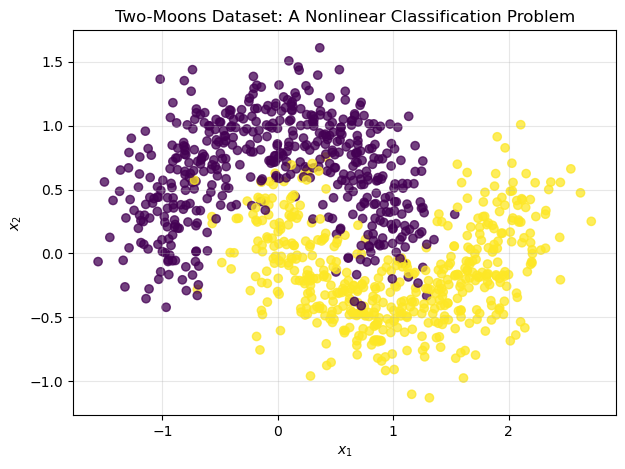

In [15]:
# Create a nonlinear classification problem

X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), alpha=0.75)
plt.title("Two-Moons Dataset: A Nonlinear Classification Problem")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid(True, alpha=0.3)
plt.show()

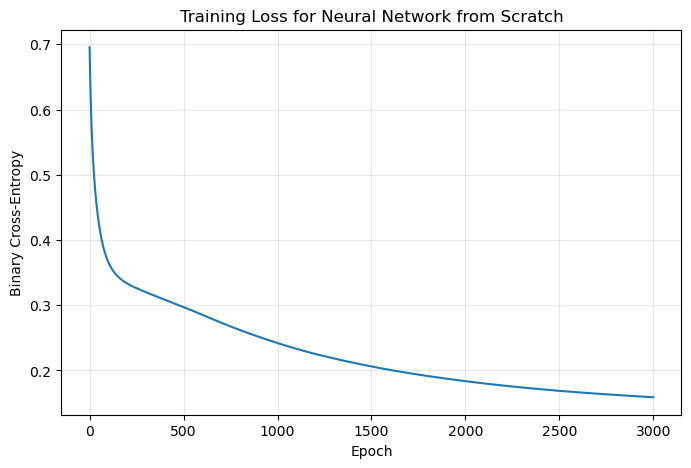

Test accuracy: 0.9533333333333334


In [17]:
# Neural network from scratch

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def bce_loss(y, p):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def initialize_params(input_dim, hidden_dim, output_dim=1, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, np.sqrt(2 / input_dim), size=(input_dim, hidden_dim))
    b1 = np.zeros((1, hidden_dim))
    W2 = rng.normal(0, np.sqrt(2 / hidden_dim), size=(hidden_dim, output_dim))
    b2 = np.zeros((1, output_dim))
    return W1, b1, W2, b2

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    P = sigmoid(Z2)
    cache = (Z1, A1, Z2, P)
    return P, cache

def train_nn(X, y, hidden_dim=12, lr=0.05, epochs=3000, seed=42):
    n, input_dim = X.shape
    W1, b1, W2, b2 = initialize_params(input_dim, hidden_dim, 1, seed)
    losses = []

    for epoch in range(epochs):
        # Forward
        P, cache = forward(X, W1, b1, W2, b2)
        Z1, A1, Z2, P = cache

        # Loss
        loss = bce_loss(y, P)
        losses.append(loss)

        # Backward pass
        dZ2 = (P - y) / n
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Parameter updates
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return W1, b1, W2, b2, losses

W1, b1, W2, b2, losses = train_nn(X_train_s, y_train, hidden_dim=16, lr=0.05, epochs=3000)

plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title("Training Loss for Neural Network from Scratch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.grid(True, alpha=0.3)
plt.show()

P_test, _ = forward(X_test_s, W1, b1, W2, b2)
y_pred = (P_test >= 0.5).astype(int)

print("Test accuracy:", accuracy_score(y_test, y_pred))

In [19]:
# Compare with logistic regression

logit = LogisticRegression()
logit.fit(X_train_s, y_train.ravel())
logit_pred = logit.predict(X_test_s)

print("Logistic regression test accuracy:", accuracy_score(y_test, logit_pred))
print("Neural network test accuracy:", accuracy_score(y_test, y_pred))

Logistic regression test accuracy: 0.89
Neural network test accuracy: 0.9533333333333334


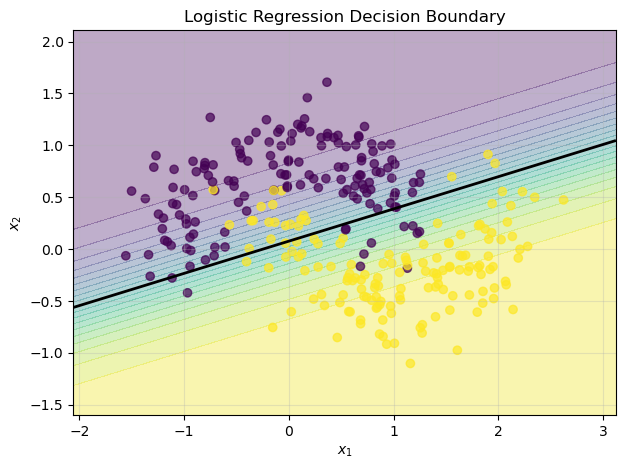

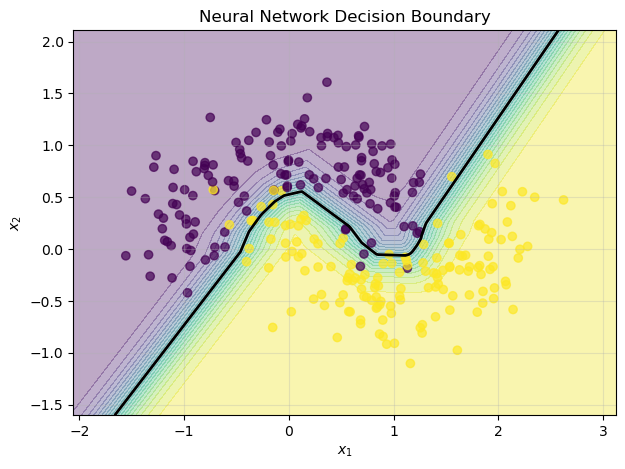

In [21]:
# Decision boundary plots

def plot_decision_boundary_predictor(predict_proba_function, X_raw, y_raw, title, scaler=None):
    x_min, x_max = X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5
    y_min, y_max = X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_in = scaler.transform(grid) if scaler is not None else grid
    probs = predict_proba_function(grid_in).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, probs, levels=20, alpha=0.35)
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
    plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y_raw.ravel(), alpha=0.70)
    plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary_predictor(
    lambda G: logit.predict_proba(G)[:, 1],
    X_test, y_test,
    "Logistic Regression Decision Boundary",
    scaler=scaler
)

plot_decision_boundary_predictor(
    lambda G: forward(G, W1, b1, W2, b2)[0].ravel(),
    X_test, y_test,
    "Neural Network Decision Boundary",
    scaler=scaler
)

## 10. Initialization

Initialization matters because the network must start with weights that allow gradients to flow.

If all weights are initialized to the same value, hidden units learn the same features. This is called a symmetry problem. Random initialization breaks symmetry.

A common initialization for ReLU networks is **He initialization**:

$$
W_{ij} \sim N\left(0,\frac{2}{n_{in}}\right),
$$

where $n_{in}$ is the number of inputs into the layer.

For tanh or sigmoid networks, **Xavier initialization** is common:

$$
W_{ij} \sim N\left(0,\frac{1}{n_{in}}\right).
$$

Good initialization helps avoid exploding or vanishing activations and gradients.

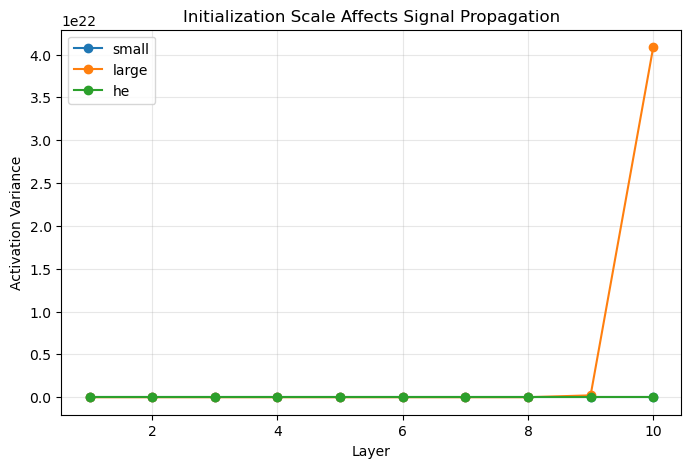

In [23]:
# Demonstrating how initialization scale affects activations through layers

np.random.seed(42)
n_samples = 1000
width = 100
depth = 10
X_init = np.random.normal(0, 1, size=(n_samples, width))

def activation_variances(scale_rule):
    A = X_init.copy()
    variances = []
    for layer in range(depth):
        if scale_rule == "small":
            W = np.random.normal(0, 0.05, size=(width, width))
        elif scale_rule == "large":
            W = np.random.normal(0, 2.0, size=(width, width))
        elif scale_rule == "he":
            W = np.random.normal(0, np.sqrt(2 / width), size=(width, width))
        Z = A @ W
        A = np.maximum(0, Z)
        variances.append(np.var(A))
    return variances

plt.figure(figsize=(8, 5))
for rule in ["small", "large", "he"]:
    plt.plot(range(1, depth + 1), activation_variances(rule), marker="o", label=rule)
plt.xlabel("Layer")
plt.ylabel("Activation Variance")
plt.title("Initialization Scale Affects Signal Propagation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Learning Rates

The learning rate $\eta$ determines the size of parameter updates.

$$
\theta^{(m+1)}
=
\theta^{(m)}
-
\eta\nabla_\theta L(\theta^{(m)}).
$$

Practical consequences:

- Too small: training is slow.
- Too large: loss may oscillate or diverge.
- Moderate: training converges efficiently.

Modern optimizers such as Adam adapt learning rates across parameters, but the initial learning rate still matters.

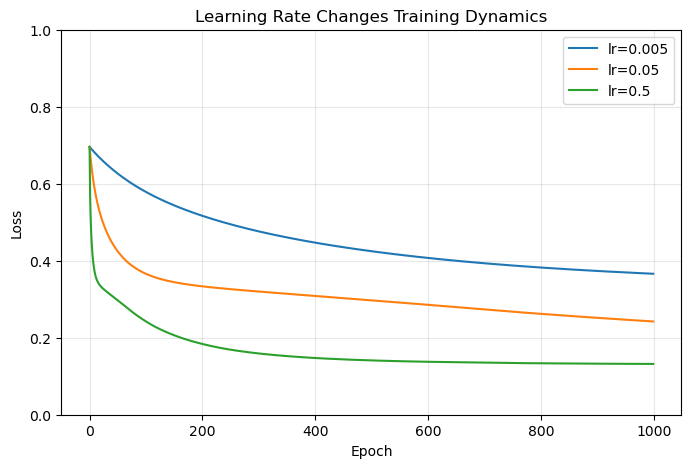

In [25]:
# Compare learning rates on the same neural network

learning_rates = [0.005, 0.05, 0.5]
loss_by_lr = {}

for lr in learning_rates:
    _, _, _, _, losses_lr = train_nn(X_train_s, y_train, hidden_dim=16, lr=lr, epochs=1000, seed=42)
    loss_by_lr[lr] = losses_lr

plt.figure(figsize=(8, 5))
for lr, lhist in loss_by_lr.items():
    plt.plot(lhist, label=f"lr={lr}")
plt.ylim(0, 1.0)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Changes Training Dynamics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Regularization and Overfitting

Neural networks can overfit because they have many parameters.

Common regularization methods include:

### Weight decay

Weight decay penalizes large weights:

$$
L_{regularized}
=
L
+
\lambda \sum_j w_j^2.
$$

This is analogous to Ridge regression.

### Dropout

Dropout randomly sets some hidden activations to zero during training. If $d_j$ is a Bernoulli random variable, a dropout layer uses

$$
\tilde{a}_j = d_j a_j,
$$

where

$$
d_j \sim Bernoulli(q).
$$

Here $q$ is the probability that a unit is kept. Dropout prevents the network from relying too much on any single hidden unit.

### Early stopping

Stop training when validation loss stops improving.

### Data augmentation

For images, text, and audio, artificial transformations can increase effective sample size.

In [27]:
# Overfitting demonstration using sklearn's MLPClassifier

X_small, y_small = make_moons(n_samples=220, noise=0.30, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_small, y_small, test_size=0.40, random_state=42, stratify=y_small)

overfit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(100, 100), alpha=0.000001, max_iter=4000, random_state=42))
])

regularized_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(30, 30), alpha=0.05, max_iter=4000, random_state=42))
])

overfit_model.fit(X_tr, y_tr)
regularized_model.fit(X_tr, y_tr)

for name, model in [("Large weakly regularized network", overfit_model), ("Smaller regularized network", regularized_model)]:
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    test_acc = accuracy_score(y_te, model.predict(X_te))
    print(f"{name}: train accuracy={train_acc:.3f}, test accuracy={test_acc:.3f}")

Large weakly regularized network: train accuracy=0.985, test accuracy=0.875
Smaller regularized network: train accuracy=0.924, test accuracy=0.886


## 13. Feedforward Networks

A **feedforward neural network** sends information in one direction: from inputs to hidden layers to outputs. There are no loops.

Feedforward networks are suitable for:

- Tabular prediction.
- Credit scoring.
- Fraud detection.
- Demand forecasting.
- Nonlinear regression.
- Binary and multi-class classification.

Mathematically, a deep feedforward network is a composition of functions:

$$
f(x)
=
f_L(f_{L-1}(\cdots f_2(f_1(x)))).
$$

This composition structure is why neural networks can approximate highly nonlinear functions.

Digits test accuracy: 0.9666666666666667


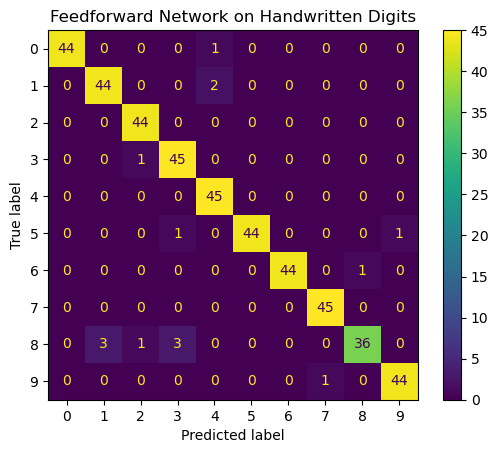

In [29]:
# Feedforward network for the digits dataset

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.25, random_state=42, stratify=y_digits
)

ffn_digits = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(hidden_layer_sizes=(80, 40), alpha=0.001, max_iter=2000, random_state=42))
])

ffn_digits.fit(X_train_d, y_train_d)
pred_digits = ffn_digits.predict(X_test_d)

print("Digits test accuracy:", accuracy_score(y_test_d, pred_digits))

ConfusionMatrixDisplay.from_predictions(y_test_d, pred_digits)
plt.title("Feedforward Network on Handwritten Digits")
plt.show()

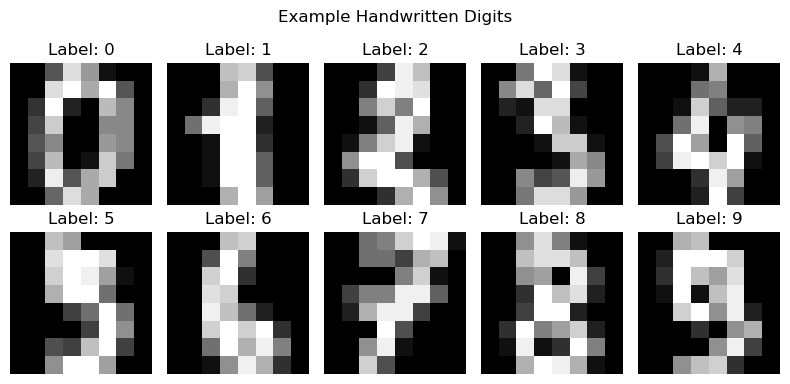

In [31]:
# Show example digit images

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(digits.images[idx], cmap="gray")
    ax.set_title(f"Label: {digits.target[idx]}")
    ax.axis("off")
plt.suptitle("Example Handwritten Digits")
plt.tight_layout()
plt.show()

## 14. Convolutional Neural Networks

A **convolutional neural network**, or CNN, is designed for grid-like data such as images.

An image has local spatial structure. Nearby pixels matter together. CNNs exploit this by using filters, also called kernels, that slide across the image.

A convolution operation computes local weighted sums:

$$
Z_{ij}
=
\sum_{a}\sum_{b}
K_{ab}X_{i+a,j+b}.
$$

Here:

- $X$ is an image or feature map.
- $K$ is a filter.
- $Z$ is the resulting feature map.

CNNs use:

1. **Convolutional layers** to detect local patterns.
2. **Activation functions** such as ReLU.
3. **Pooling layers** to reduce spatial dimensions.
4. **Fully connected layers** for final prediction.

In computer vision, early convolutional filters often detect edges and textures. Deeper layers detect shapes, object parts, or whole objects.

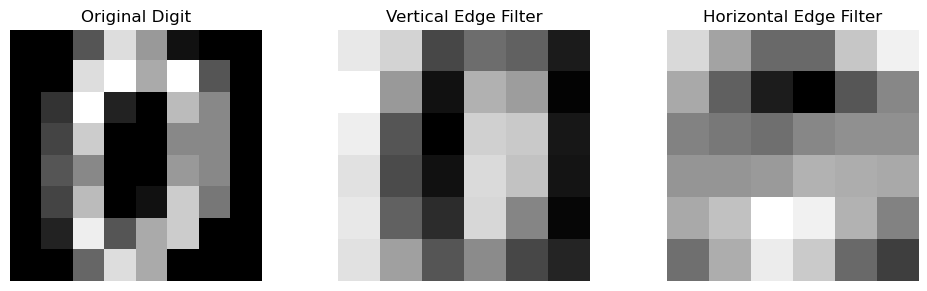

In [33]:
# Manual convolution example on a digit image

image = digits.images[0]

# Simple edge-detection filters
vertical_edge = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

horizontal_edge = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
])

def convolve2d(img, kernel):
    kh, kw = kernel.shape
    h, w = img.shape
    out = np.zeros((h - kh + 1, w - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(img[i:i+kh, j:j+kw] * kernel)
    return out

v_edges = convolve2d(image, vertical_edge)
h_edges = convolve2d(image, horizontal_edge)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Digit")
axes[1].imshow(v_edges, cmap="gray")
axes[1].set_title("Vertical Edge Filter")
axes[2].imshow(h_edges, cmap="gray")
axes[2].set_title("Horizontal Edge Filter")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 15. Recurrent Neural Networks

A **recurrent neural network**, or RNN, is designed for sequential data. Examples include:

- Text.
- Speech.
- Time series.
- Financial returns.
- Macroeconomic indicators.
- Transaction histories.

An RNN maintains a hidden state:

$$
h_t = \phi(W_xx_t + W_hh_{t-1}+b),
$$

and produces an output

$$
\hat{y}_t = g(W_yh_t+c).
$$

The hidden state allows information from earlier time steps to affect later predictions.

Classic RNNs can struggle with long-range dependencies because gradients may vanish or explode. Modern sequence models use architectures such as LSTMs, GRUs, and transformers.

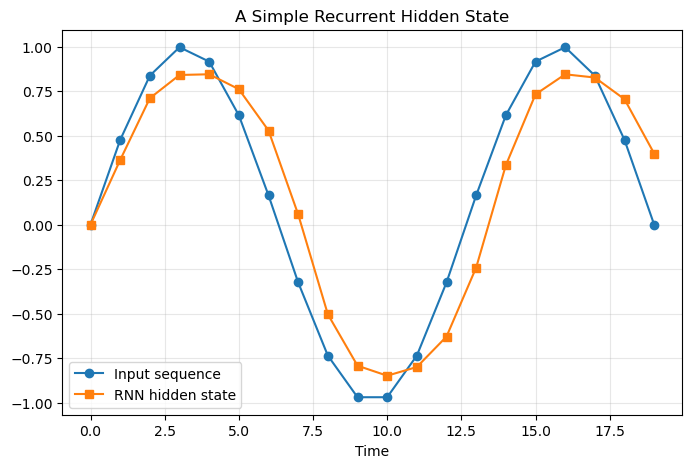

In [35]:
# Simple recurrent calculation by hand

np.random.seed(42)

T = 20
x_seq = np.sin(np.linspace(0, 3*np.pi, T)).reshape(-1, 1)

W_x = np.array([[0.8]])
W_h = np.array([[0.6]])
b = np.array([[0.0]])

h = np.zeros((1, 1))
hidden_states = []

for t in range(T):
    x_t = x_seq[t:t+1]
    h = np.tanh(x_t @ W_x + h @ W_h + b)
    hidden_states.append(h.item())

plt.figure(figsize=(8, 5))
plt.plot(x_seq.ravel(), marker="o", label="Input sequence")
plt.plot(hidden_states, marker="s", label="RNN hidden state")
plt.title("A Simple Recurrent Hidden State")
plt.xlabel("Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 16. Neural Networks and Feature Learning

The major advantage of neural networks over many traditional methods is **feature learning**.

A traditional workflow often looks like:

$$
\text{raw data}
\rightarrow
\text{hand-designed features}
\rightarrow
\text{model}.
$$

A deep-learning workflow often looks like:

$$
\text{raw data}
\rightarrow
\text{learned features}
\rightarrow
\text{prediction}.
$$

The hidden layers learn transformations of the inputs. These transformations can be more useful for prediction than the raw variables.

Examples:

- A CNN learns edges, textures, and shapes from pixels.
- A language model learns token embeddings and contextual meaning.
- A finance model may learn nonlinear interactions among firm characteristics and macro variables.

## 17. Neural Networks in Real-World Applications

### Computer vision

CNNs are used for:

- Image classification.
- Object detection.
- Medical imaging.
- Satellite imagery.
- Quality control in manufacturing.

### Natural language processing

Neural networks are used for:

- Text classification.
- Translation.
- Sentiment analysis.
- Question answering.
- Summarization.
- Chatbots and language models.

### Finance and economics

Neural networks are used for:

- Credit scoring.
- Fraud detection.
- Bankruptcy prediction.
- Volatility forecasting.
- Option pricing approximations.
- Demand forecasting.
- Nowcasting economic activity.
- Alternative-data analysis.

### Generative AI

Generative AI uses neural networks to produce new content:

- Text.
- Images.
- Audio.
- Code.
- Synthetic data.

Modern generative AI often uses transformer architectures, diffusion models, or other deep generative structures. The principle remains the same: learn a flexible function from data and use it to generate or predict.

## 18. Best Practices

### Scale inputs

Neural networks train better when inputs are standardized:

$$
x_{standardized}
=
\frac{x-\bar{x}}{s_x}.
$$

### Use train/validation/test splits

Do not evaluate final performance on the same data used to tune the model.

### Start simple

A smaller network with good preprocessing often beats a huge network with poor validation.

### Monitor validation loss

Training loss can keep falling while validation loss rises. That is overfitting.

### Tune learning rates

The learning rate is often one of the most important hyperparameters.

### Regularize

Use weight decay, dropout, early stopping, or data augmentation.

### Check calibration and errors

For classification, do not report accuracy alone. Inspect confusion matrices, precision, recall, and probability calibration.

### Beware causal interpretations

A neural network is not automatically a causal model. High predictive accuracy does not imply that the features causally determine the outcome.

## 19. Summary

Neural networks are powerful because they combine:

1. Linear transformations.
2. Nonlinear activation functions.
3. Layered architectures.
4. Loss-function minimization.
5. Gradient-based optimization.
6. Backpropagation.

The basic unit is

$$
a=\phi(w'x+b).
$$

A network stacks many such units to learn

$$
\hat{y}=f_\theta(x).
$$

The core training loop is:

1. Forward propagate inputs.
2. Compute predictions.
3. Compute loss.
4. Backpropagate gradients.
5. Update weights and biases.
6. Repeat until performance stabilizes.

Feedforward networks work well for tabular data. CNNs exploit spatial structure in images. RNNs and related models exploit sequential structure. Modern generative AI extends these ideas to produce text, images, audio, and code.

The conceptual lesson is that neural networks are not mysterious. They are flexible nonlinear statistical models trained by gradient-based optimization.